In [ ]:
import pandas as pd
# Replace 'your_file.csv' with your actual file path
df = pd.read_csv('BotnetFull.csv')
# Show the first 5 rows to verify

In [ ]:

# dropout layer with p = 0.5

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8774 - loss: 0.3925 - val_accuracy: 0.9675 - val_loss: 0.1291
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9778 - loss: 0.0951 - val_accuracy: 0.9783 - val_loss: 0.0909
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9847 - loss: 0.0641 - val_accuracy: 0.9783 - val_loss: 0.0800
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9801 - loss: 0.0633 - val_accuracy: 0.9783 - val_loss: 0.0766
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9854 - loss: 0.0548 - val_accuracy: 0.9783 - val_loss: 0.0747
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9846 - loss: 0.0425 - val_accuracy: 0.9783 - val_loss: 0.0676
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9863 - loss: 0.0427 - val_accuracy: 0.9783 - val_loss: 0.0690
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9830 - loss: 0.0426 - val_accuracy: 0.9783 - val_loss: 0.0667
E

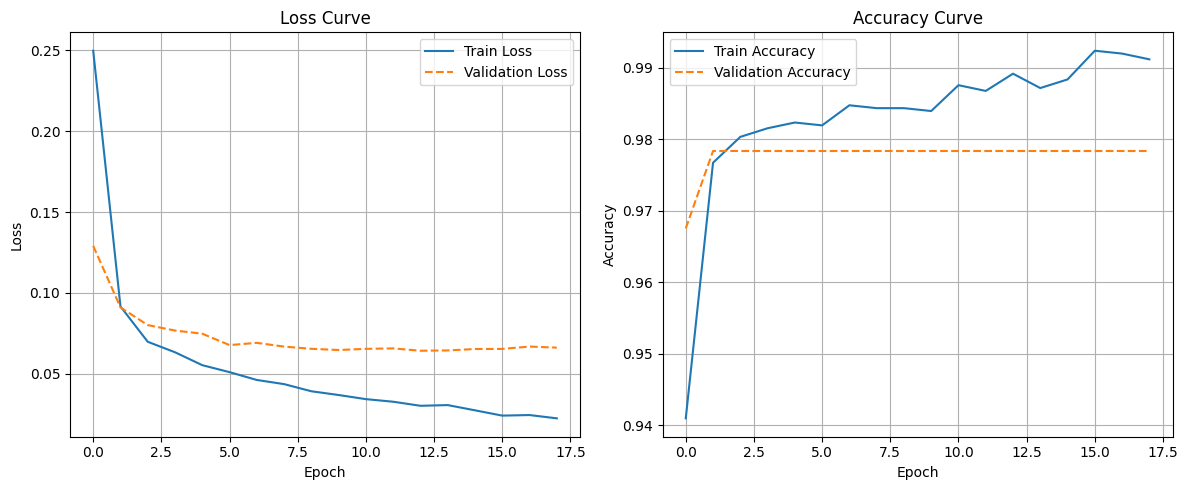

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu'),  # Hidden layer
    Dropout(0.5),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid')                      # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# # Step 11: Save the model
# model.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [ ]:
#p = 0.4 for the dropout layer

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8681 - loss: 0.3790 - val_accuracy: 0.9711 - val_loss: 0.1244
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9803 - loss: 0.0887 - val_accuracy: 0.9783 - val_loss: 0.0876
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9792 - loss: 0.0705 - val_accuracy: 0.9783 - val_loss: 0.0788
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9878 - loss: 0.0549 - val_accuracy: 0.9819 - val_loss: 0.0725
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.9783 - val_loss: 0.0703
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9814 - loss: 0.0598 - val_accuracy: 0.9783 - val_loss: 0.0681
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9793 - loss: 0.0505 - val_accuracy: 0.9783 - val_loss: 0.0688
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9842 - loss: 0.0427 - val_accuracy: 0.9783 - val_loss: 0.0694
Epo

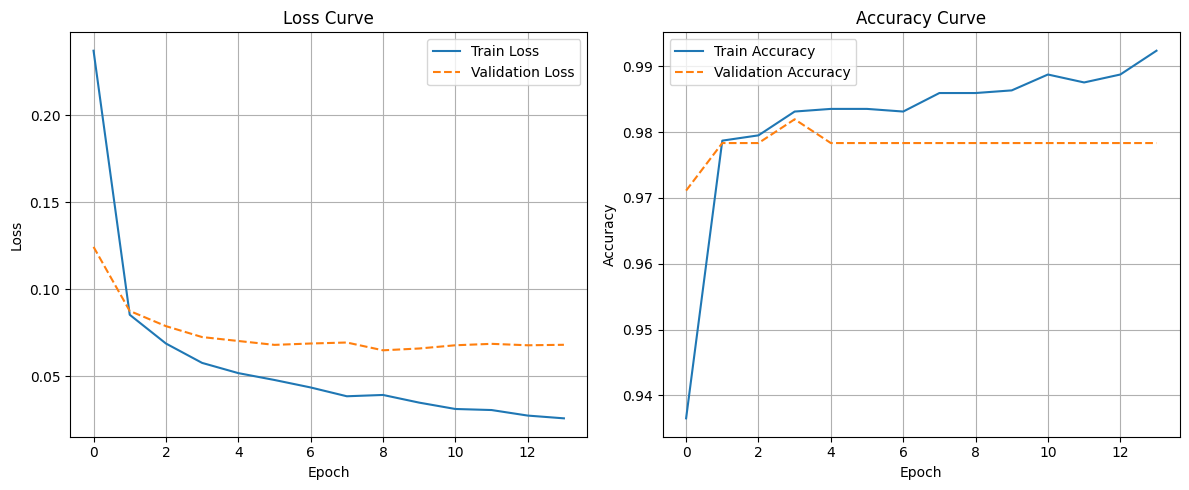

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu'),  # Hidden layer
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid')                      # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
# model.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [ ]:
#p = 0.3 ,

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9068 - loss: 0.3682 - val_accuracy: 0.9711 - val_loss: 0.1246
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9756 - loss: 0.0966 - val_accuracy: 0.9783 - val_loss: 0.0864
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9790 - loss: 0.0725 - val_accuracy: 0.9783 - val_loss: 0.0786
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9814 - loss: 0.0652 - val_accuracy: 0.9783 - val_loss: 0.0732
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.9783 - val_loss: 0.0725
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9850 - loss: 0.0426 - val_accuracy: 0.9819 - val_loss: 0.0682
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9848 - loss: 0.0412 - val_accuracy: 0.9783 - val_loss: 0.0694
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9868 - loss: 0.0365 - val_accuracy: 0.9747 - val_loss: 0.0699
Ep

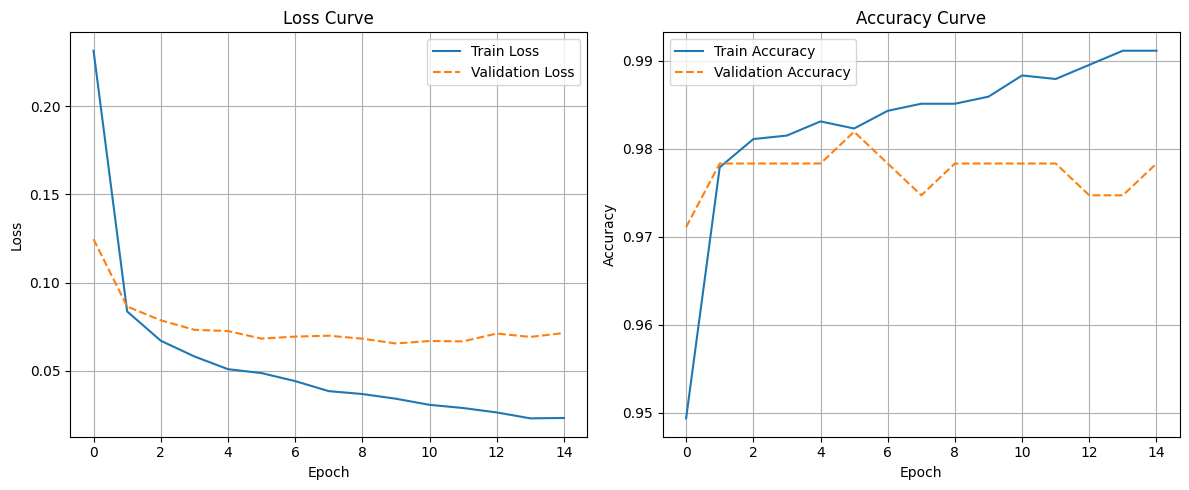

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu'),  # Hidden layer
    Dropout(0.3),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid')                      # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
# model.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [ ]:
#p=0.2

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8911 - loss: 0.3681 - val_accuracy: 0.9675 - val_loss: 0.1164
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9718 - loss: 0.0928 - val_accuracy: 0.9783 - val_loss: 0.0838
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9835 - loss: 0.0686 - val_accuracy: 0.9783 - val_loss: 0.0754
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9875 - loss: 0.0543 - val_accuracy: 0.9783 - val_loss: 0.0691
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9855 - loss: 0.0472 - val_accuracy: 0.9783 - val_loss: 0.0667
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9841 - loss: 0.0427 - val_accuracy: 0.9819 - val_loss: 0.0640
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9856 - loss: 0.0388 - val_accuracy: 0.9819 - val_loss: 0.0659
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9845 - loss: 0.0456 - val_accuracy: 0.9783 - val_loss: 0.0654
Ep

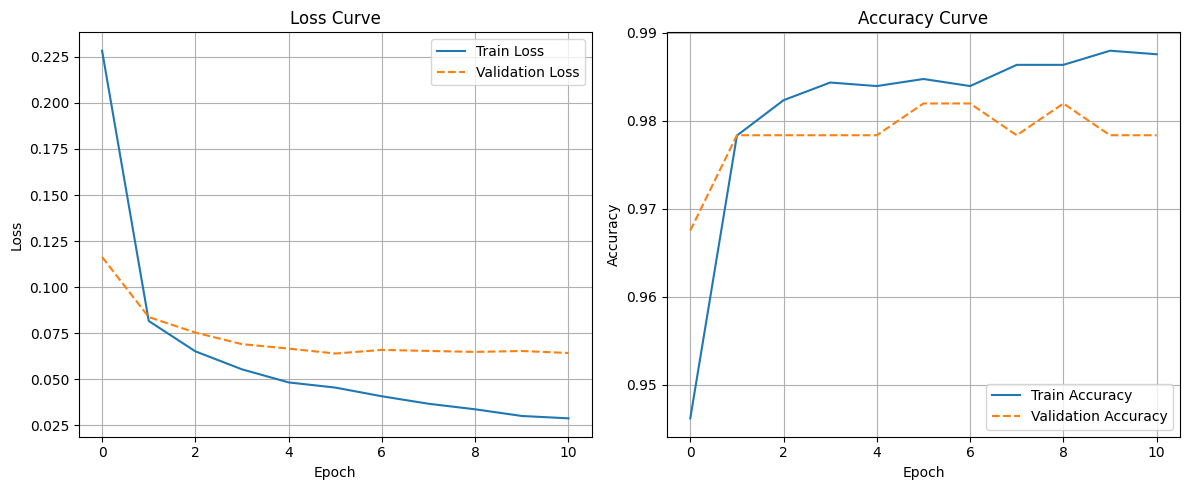

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu'),  # Hidden layer
    Dropout(0.2),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid')                      # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
# model.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [ ]:
# CONCLUSION : most optimum value of p = 0.4